In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
# from scipy.conftest import xp_available_backends
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

from scipy.stats import differential_entropy

import utility_functions as uf

In [2]:
year = 2023
mode = "individual"

In [8]:
df_cf = (
    pd.read_csv(uf.PATH+f"df_country_subfield/{mode}_{year}.csv", index_col=0)
    .T
    .merge(uf.df_topics[["subfield_id", "field_id"]].drop_duplicates().assign(subfield_str=lambda df: df.subfield_id.astype(str)).set_index("subfield_str"),
           left_index=True, right_index=True)
    .drop(columns=["subfield_id"])
    .assign(field_str=lambda df: df.field_id.astype(str))
    .drop(columns=["field_id"])
    .groupby("field_str")
    .sum()
    .T
)
df_cf

field_str,11,12,13,14,15,16,17,18,19,20,...,27,28,29,30,31,32,33,34,35,36
AD,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,1.0
AE,100.0,106.0,133.0,264.0,25.0,43.0,709.0,81.0,57.0,123.0,...,775.0,67.0,10.0,8.0,69.0,184.0,562.0,1.0,54.0,126.0
AF,29.0,31.0,9.0,41.0,0.0,1.0,30.0,1.0,1.0,8.0,...,81.0,1.0,2.0,1.0,1.0,20.0,183.0,0.0,7.0,15.0
AG,0.0,0.0,9.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,77.0,3.0,1.0,3.0,0.0,2.0,2.0,0.0,5.0,5.0
AL,39.0,59.0,10.0,70.0,2.0,0.0,52.0,14.0,13.0,61.0,...,141.0,2.0,2.0,1.0,5.0,32.0,281.0,0.0,7.0,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,0.0
YE,31.0,36.0,16.0,35.0,1.0,15.0,78.0,17.0,9.0,48.0,...,276.0,2.0,11.0,16.0,24.0,17.0,108.0,0.0,21.0,43.0
ZA,1174.0,832.0,572.0,1156.0,39.0,184.0,959.0,304.0,193.0,754.0,...,2603.0,105.0,138.0,43.0,275.0,792.0,4502.0,28.0,39.0,683.0
ZM,46.0,15.0,14.0,86.0,1.0,1.0,34.0,15.0,2.0,55.0,...,121.0,0.0,5.0,1.0,4.0,21.0,137.0,0.0,1.0,35.0


In [9]:
df_prob = df_cf.div(df_cf.sum(axis=1), axis=0)

In [10]:
field_tree = uf.get_field_tree(uf.df_topics)

In [13]:
df_dist = uf.get_w1_distances(field_tree, df_prob, subfield_mode=False)

(array([ 222.,  106.,  514.,  894., 1374., 1788., 2086., 2556., 2500.,
        2662., 2574., 2636., 2414., 2330., 2116., 2008., 1730., 1552.,
        1444., 1288., 1102., 1074.,  906.,  798.,  770.,  688.,  538.,
         584.,  438.,  478.,  406.,  416.,  376.,  310.,  316.,  314.,
         296.,  250.,  258.,  224.,  166.,  192.,  118.,  140.,  190.,
         162.,  126.,   72.,   42.,  112.]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]),
 <BarContainer object of 50 artists>)

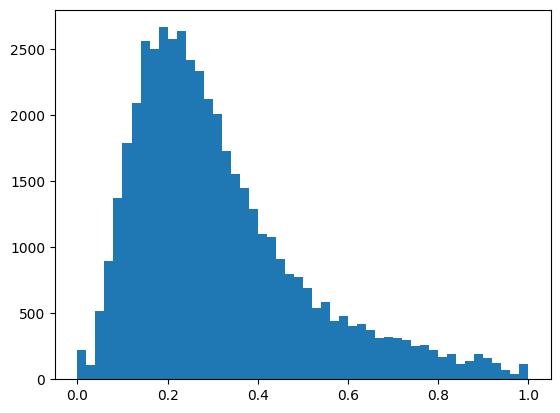

In [14]:
plt.hist(df_dist.values.flatten(), bins=50)

In [15]:
D = df_dist.fillna(0).values
# D = np.atan(3*df_dist.fillna(0).values)

In [18]:
condensed_D = squareform(D)

Z = linkage(condensed_D, method='average')

labels1 = fcluster(Z, t=0.2, criterion='distance')

score = silhouette_score(D, labels1, metric="precomputed")
score

np.float64(0.2507898149715168)

In [19]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=10, metric='precomputed', linkage='average')

labels = model.fit_predict(D)

score = silhouette_score(D, labels, metric="precomputed")
score

np.float64(0.26522895102160343)

In [ ]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.2, min_samples=3, metric='precomputed')
labels = model.fit_predict(D)
score = silhouette_score(D, labels, metric="precomputed")
score

np.float64(0.5317002120478663)

In [21]:
from sklearn.cluster import OPTICS

model = OPTICS(metric='precomputed', min_samples=2, max_eps=0.2)
labels = model.fit_predict(D)
score = silhouette_score(D, labels, metric="precomputed")
score

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_optics.py:1086: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


np.float64(-0.04481909590226102)

In [22]:
from sklearn.cluster import SpectralClustering
import numpy as np

# Convert distance -> similarity
sigma = 0.01
affinity = np.exp(-D**2 / (2 * sigma**2))

model = SpectralClustering(n_clusters=5, affinity='precomputed')
labels = model.fit_predict(affinity)
score = silhouette_score(D, labels, metric="precomputed")
score

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/sparse/linalg/_eigen/lobpcg/lobpcg.py:79: RuntimeWarning: divide by zero encountered in matmul
  np.matmul(x, y, out=x)
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/sparse/linalg/_eigen/lobpcg/lobpcg.py:79: RuntimeWarning: overflow encountered in matmul
  np.matmul(x, y, out=x)
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/sparse/linalg/_eigen/lobpcg/lobpcg.py:79: RuntimeWarning: invalid value encountered in matmul
  np.matmul(x, y, out=x)
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/sparse/linalg/_eigen/lobpcg/lobpcg.py:66: RuntimeWarning: divide by zero encountered in matmul
  return lambda v: m @ v
/Users/irinavorobeva/Library

np.float64(0.15303990501803108)

In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [30]:
# X: country x subfield matrix
# Example: df.values or df.to_numpy()
X = df_prob.fillna(0).values  

# Standardize so each feature has mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Keep n_components = number of dimensions you want, e.g., 20
pca = PCA(n_components=8, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape of components:", pca.components_.shape)
print("Explained variance per component:", pca.explained_variance_)
print("Explained variance ratio:", pca.explained_variance_ratio_, " Total variance explained: ", pca.explained_variance_ratio_.sum())

Shape of components: (8, 26)
Explained variance per component: [4.56047158 1.93828925 1.82012486 1.72356461 1.45600083 1.35558823
 1.18790962 1.12895246]
Explained variance ratio: [0.1745907  0.07420445 0.06968071 0.06598404 0.05574077 0.05189663
 0.04547731 0.04322022]  Total variance explained:  0.5807948380891621


[2 3 2 0 2 3 2 1 2 1 1 2 3 2 1 3 1 0 3 2 1 0 2 3 2 2 1 2 3 3 2 1 0 0 0 1 0
 1 0 3 0 2 2 2 1 3 1 2 1 0 2 3 2 3 3 0 1 0 1 2 2 2 2 1 0 1 0 2 0 2 2 2 0 0
 2 2 3 2 2 2 0 3 2 1 2 1 2 1 1 3 3 3 1 1 2 3 3 2 2 2 2 1 0 3 3 2 3 2 1 0 2
 3 0 2 3 3 3 3 3 2 2 1 0 3 0 2 3 1 0 0 0 3 2 2 2 3 3 2 2 0 0 0 1 1 0 2 1 3
 2 2 2 0 2 3 3 1 2 1 2 2 3 2 3 3 3 0 3 2 0 0 1 3 3 2 3 2 2 0 2 2 2 2 2 3 2
 2 0 0 3 3 2 2 3 2 1 2 2 3 0 3 0 1 0 3 2 0 2 2 2 3 2 2 3 3 2 2]
Score:  0.3240607267385341


/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


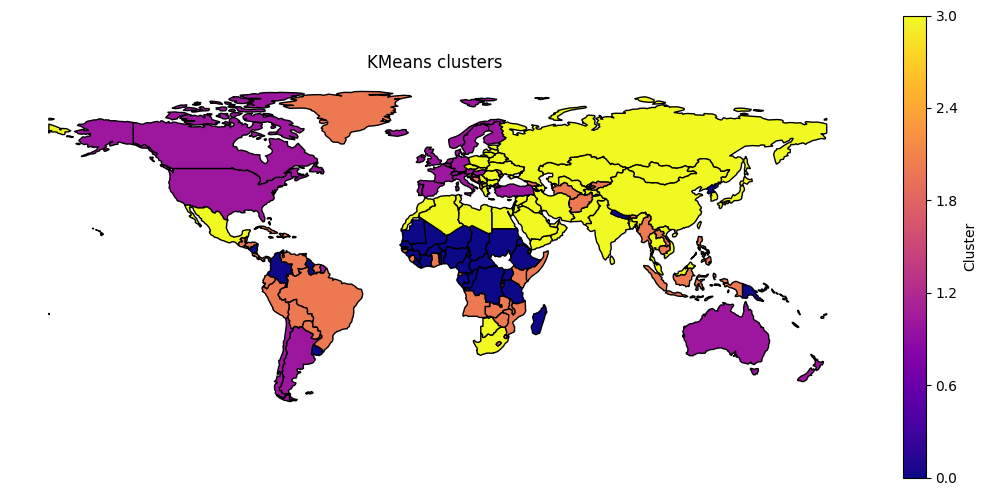

In [33]:
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans

# X = your vectors (countries x features)
X_norm = normalize(X_pca, axis=1)  # optional if you want cosine-like behavior

kmeans = KMeans(n_clusters=4, n_init=20, random_state=42)
labels = kmeans.fit_predict(X_norm)

print(labels)  # cluster assignment for each country

score = silhouette_score(X_pca, labels, metric="cosine")
print("Score: ", score)

df_map = (
    pd.DataFrame(index=df_prob.index)
    .assign(labels=labels)
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2")
)

_, _ = uf.plot_map_continuous(
    df_map, column="labels", title="KMeans clusters", legend="Cluster",
)